# **Ievads attēlu apstrādē**
## **Praktiskais darbs Nr. 5**
---

**Students:** Rihards Irbe  

**Studenta apliecības Nr.:** 251RDB259

**Saite uz programmēšanas kodu:** https://colab.research.google.com/drive/1HjlZLNShpO_0XZAScYWcK49eU56ihFib?authuser=2#scrollTo=Gz_9b9xw5L_C&line=8&uniqifier=1

---

## **Programmas kods ar izvadi**
*Darbā jābūt iekļautam palaistam Python kodam, t. i., kodam jābūt izpildītam tā, lai dokumentā būtu redzamas visas vizualizācijas, attēli, grafiki un cita programmas izvade. Nepalaists kods vai kods bez redzamiem rezultātiem netiks uzskatīts par korekti iesniegtu. Kodam jābūt bez komentāriem.*

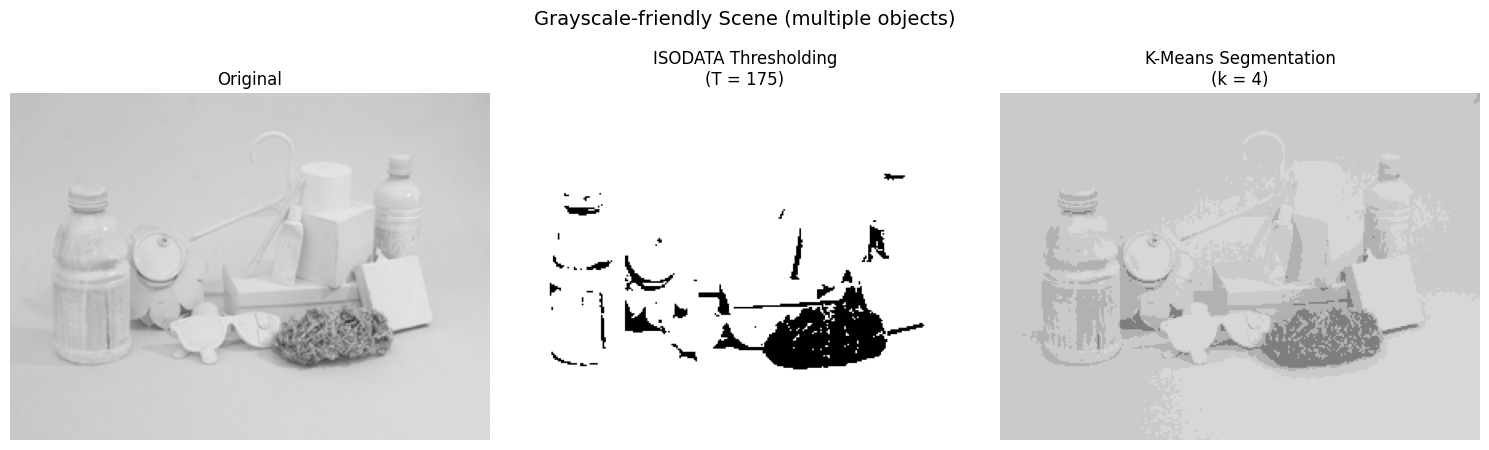

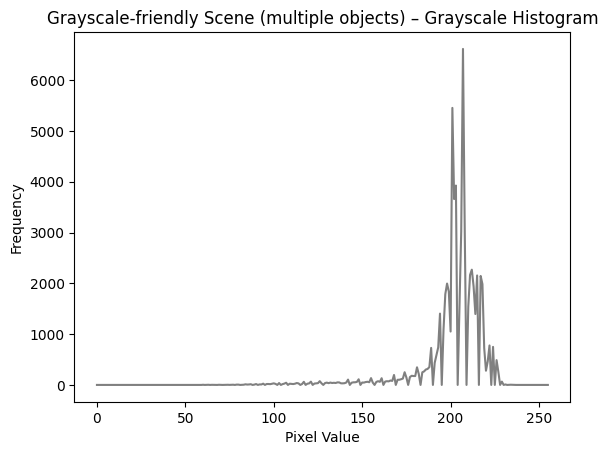

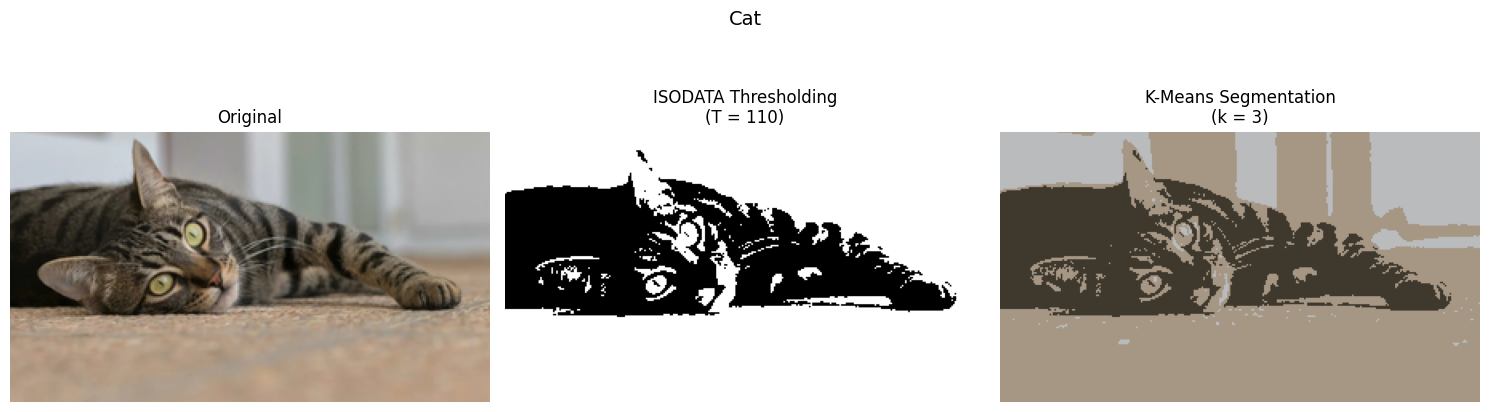

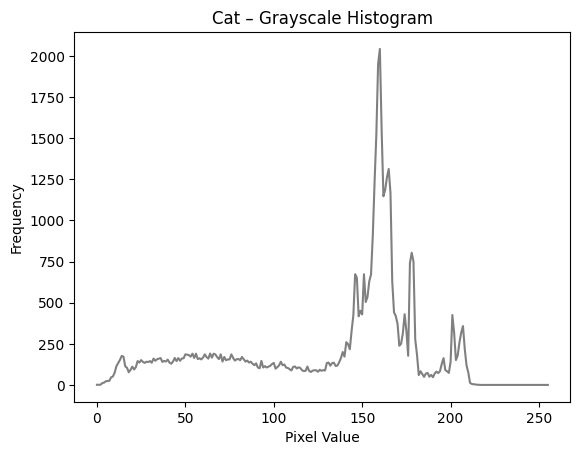

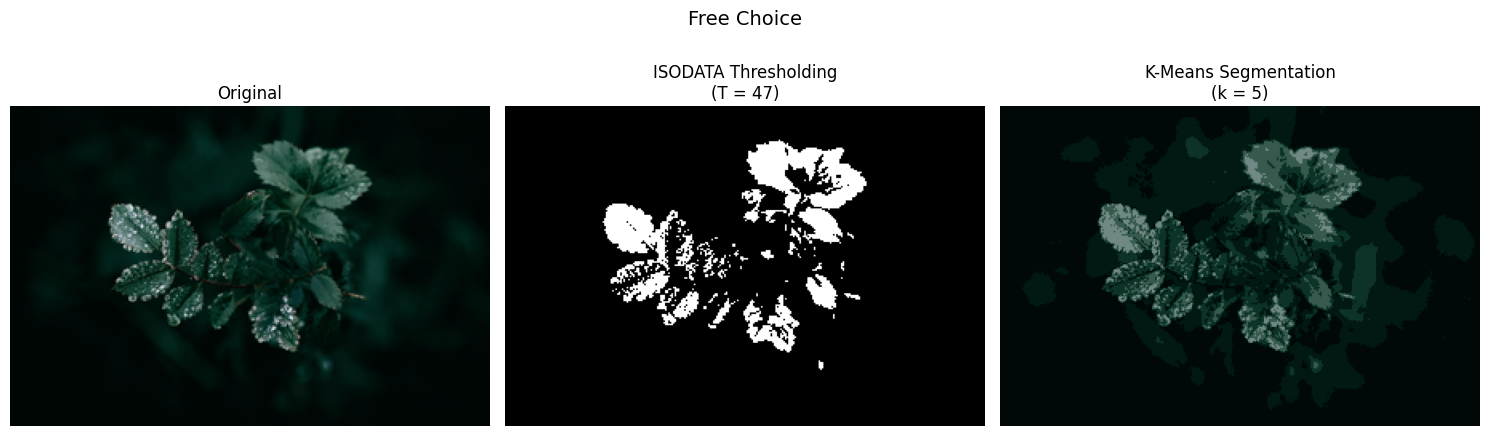

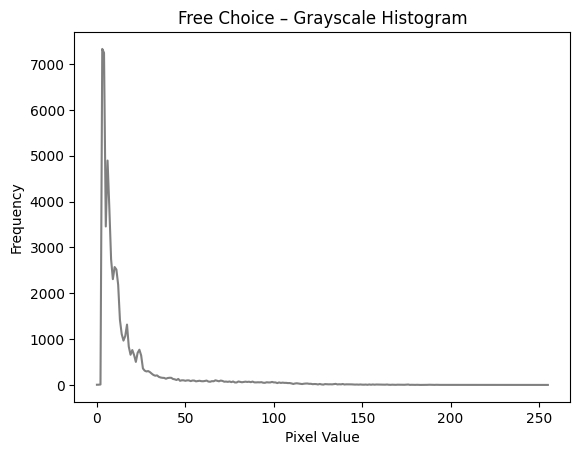

In [ ]:
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np


def load_image(url):

    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    response = requests.get(url, headers=headers)
    img = Image.open(BytesIO(response.content)).convert("RGB")

    img.thumbnail((300, 300), Image.LANCZOS)

    return img


def to_grayscale(image):

    width, height = image.size
    pixels = image.load()

    gray_img = Image.new("L", (width, height))
    gray_pixels = gray_img.load()

    for x in range(width):
        for y in range(height):

            r = pixels[x, y][0]
            g = pixels[x, y][1]
            b = pixels[x, y][2]

            gray_pixels[x, y] = int(0.299 * r + 0.587 * g + 0.114 * b)

    return gray_img


def calculate_mean(pixels):

    total = 0
    for value in pixels:
        total += value
    return total / len(pixels)


def isodata_threshold(image):

    gray = to_grayscale(image)
    pixels = np.array(list(gray.getdata()), dtype=np.float32)

    T = calculate_mean(pixels)

    while True:

        below = pixels[pixels <= T]
        above = pixels[pixels > T]

        mu1 = calculate_mean(below) if len(below) > 0 else 0.0
        mu2 = calculate_mean(above) if len(above) > 0 else 255.0

        T_new = (mu1 + mu2) / 2.0

        if abs(T_new - T) < 0.5:
            break

        T = T_new

    T = int(T)

    width, height = gray.size
    result = Image.new("L", (width, height))
    result_pixels = result.load()
    gray_pixels = gray.load()

    for x in range(width):
        for y in range(height):
            result_pixels[x, y] = 255 if gray_pixels[x, y] > T else 0

    return result, T


def kmeans_segmentation(image, k=4, max_iter=20):

    width, height = image.size
    pixels = list(image.getdata())

    pixels_np = np.array(pixels, dtype=np.float32)

    np.random.seed(42)
    indices = np.random.choice(len(pixels_np), k, replace=False)
    average_colors = pixels_np[indices].copy()

    closest_random_pixel = np.zeros(len(pixels_np), dtype=int)

    for iteration in range(max_iter):

        new_closest_random_pixel = np.zeros(len(pixels_np), dtype=int)

        for i in range(len(pixels_np)):
            pixel = pixels_np[i]

            distances = []
            for color in average_colors:
                distance = np.sum((pixel - color) ** 2)
                distances.append(distance)

            new_closest_random_pixel[i] = int(np.argmin(distances))

        new_average_colors = np.zeros_like(average_colors)

        for group_id in range(k):
            members = pixels_np[new_closest_random_pixel == group_id]

            if len(members) > 0:
                new_average_colors[group_id] = members.mean(axis=0)
            else:
                new_average_colors[group_id] = average_colors[group_id]

        if np.allclose(average_colors, new_average_colors, atol=0.5):
            closest_random_pixel = new_closest_random_pixel
            average_colors = new_average_colors
            break

        closest_random_pixel = new_closest_random_pixel
        average_colors = new_average_colors

    result = Image.new("RGB", (width, height))
    result_pixels = result.load()

    idx = 0
    for y in range(height):
        for x in range(width):
            color = average_colors[closest_random_pixel[idx]]
            result_pixels[x, y] = (int(color[0]), int(color[1]), int(color[2]))
            idx += 1

    return result, int(k)

def show_segmentation_results(original, isodata_result, kmeans_result, threshold, k, title):

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(isodata_result, cmap="gray")
    plt.title(f"ISODATA Thresholding\n(T = {threshold})")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(kmeans_result)
    plt.title(f"K-Means Segmentation\n(k = {k})")
    plt.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def show_grayscale_histogram(image, title):

    gray = to_grayscale(image)
    pixels = list(gray.getdata())

    hist = [0] * 256
    for p in pixels:
        hist[p] += 1

    plt.figure()
    plt.plot(hist, color="gray")
    plt.title(title)
    plt.xlabel("Pixel Value")
    plt.ylabel("Frequency")
    plt.show()

image_configs = [
    (
        "Grayscale-friendly Scene (multiple objects)",
        "https://payload.cargocollective.com/1/16/543287/8450020/IMG_8413_900_2x.JPG",
        4
    ),
    (
        "Cat",
        "https://static1.squarespace.com/static/66ec3b49803ab81bf84f89e4/66ec3b69bf61a73d71744826/66eca14ee7ad767297ce31d4/1734296092801/?format=1500w",
        3
    ),
    (
        "Free Choice",
        "https://cdn.pixabay.com/photo/2023/10/12/17/56/after-the-rain-8311416_1280.jpg",
        5
    ),
]

for name, url, k_value in image_configs:

    img = load_image(url)

    isodata_img, threshold = isodata_threshold(img)

    kmeans_img, k_used = kmeans_segmentation(img, k=k_value)

    show_segmentation_results(img, isodata_img, kmeans_img, threshold, k_used, name)

    show_grayscale_histogram(img, name + " – Grayscale Histogram")

# **Secinājumi**

---
**Kādas vizuālās atšķirības ir redzamas starp dažādām segmentācijas metodēm?**

ISODATA sliekšņošana veido melnbaltu attēlu, kur tiek sadalīts attēls divās klasēs: priekšplāns un fons. Dēļ ko tiek zaudēta krāsu informācija un smalkākas detaļas.

K-means segmentācija saglabā šo krāsu informāciju un sadala attēlu k klasēs, kur katrs šis k attēlo savu vidējo krāsu. Rezultāts izskatās vienkāršots/miglaināks, bet tāpat var izprast šo krāsu atšķirību un nozīmi attēlā, nevis melnbaltu attēlojumu.

---

**Kura metode labāk piemērota dažādiem attēlu veidiem?**

ISODATA strādā vislabāk uz tumša fona un gaīša objekta, vai otrādi, taču  attēliem ar sarežģītu apgaismojumu vai daudziem objektiem ISODATA nesasniegs labus rezultātus.

K-Means ir universālāks, to var pielietot attēliem ar cilvēkiem, dzīvniekiem vai transportlīdzekļiem, kur ir daudz dažādu krāsu zonu. Jo lielāks k, jo detalizētāka segmentācija, taču arī lēnāka izpilde.

---

**Kādas ir katras metodes priekšrocības un trūkumi?**

*ISODATA sliekšņošana*

Plusi:
  - Netiek prasīti parametri
  - Ātra izpilde

Mīnusi:
  - Rezultāts ir melnbalts
  - Nestrādā labi uz krāsainiem attēliem


*K-Means segmentācija*

Plusi:
  - Krāsains outputs
  - Piemērots attēliem ar vairākām krāsām

Mīnusi:
  - Lēna izpilde, it īpaši ar lielāku k vērtību
  - Jāpadod vairāki parametri
  - Pielieto random, var būt mainīgi rezultāti

---
